* **Auteur :** FEUYAN TCHOUO Audric
* **Date de création :** Juillet 2026
* **Version :** 1.0.0
* **Contact :** tca1audricfeuyan@gmail.com - https://www.linkedin.com/in/feuyan-tchouo

---

### 🔓 Licence Open Source
Ce projet est distribué sous les termes de la **Licence MIT**. 

Vous êtes totalement libre d'utiliser, de modifier et de distribuer ce code à des fins personnelles, éducatives ou commerciales, à la seule condition de citer l'auteur original (**FEUYAN TCHOUO Audric**).

In [147]:
try:
    %watermark -a "FEUYAN TCHOUO Audric" -d -t -v -p numpy,matplotlib
except ImportError:
    print("Extension watermark non installée.")

Author: FEUYAN TCHOUO Audric

Date/Time: 2026-07-17 19:28:38

Python implementation: CPython
Python version       : 3.11.9
IPython version      : 9.9.0

numpy     : 1.26.4
matplotlib: 3.10.8



# Une implémentation des réseaux neuronnes : Le théorème d'approximation universel

Le théorème d'approximation universelle, initialement énoncé par **George Cybenko (1989)**, puis amélioré par **Kurt Hornik, Maxwell Stinchcombe, et Halbert White (1989)**, puis **Kurt Hornik (1991)**, suivie de **Moshe Leshno, Vladimir Ya. Lin, Allan Pinkus, et Shimon Schocken (1993)** démontre une théorie qui revolutionne aujourd'hui la façon dont les algorithmes de résolutions de problèmes fonctionnent. 

Dans sa forme classique, ce théorème démontre que pour toute fonction continue, il existe un nombre N, tel qu'un réseau de neuronnes à une seule couche cachée et comportant N neuronnes, permet d'approximer cette fonction; avec pour seule contrainte d'avoir des fonctions d'activation continues de forme sigmoïdale. Par la suite, **Kurt Hornik et al.** vont élargir le théorème à l'approximation de fonctions mesurables tout en démontrant que la capacité du perceptron mono couche (réseau de neuronnes à une seule couche cachée) n'est pas du fait de fonctions d'activations sigmoïdales, mais plutôt, une résultante du fait d'avoir une couche cachée et une combinaison d'opérations par la suite. Il ira plus loin en généralisant le choix des fonctions d'activation à de simples fonctions continues, bornées et non constantes en introduisant aussi l'approximation du gradient de la fonction à estimer. 

**Leshno et al.** sont ceux qui vont faire avancer ce théorème vers la révolution que nous observons aujourd'hui. Ils vont démontrer qu'un perceptron monocouche est un approximateur universel si et seulement si sa fonction d'activation n'est pas un polynôme, ouvrant ainsi grand la porte à des fonctions d'activation telles que la **ReLU**, la **Leaky ReLU** ou la **GELU**.

Ce théorème sous entend au final que pour tout problème complexe, il existe un perceptron monocouche à N neurones dans la couche cachée, permettant de séparer ce problème. Ce postulat est la thèse fondamentale de toutes les architecture de réseaux de neuronnes, dont N le nombre de neuronnes et plus tard, le nombre de couches cachées, sont les clés de l'approximation.



## 1- Les algorithmes traditionnels vs Les réseaux de neurones (machine learning/deep learning)

Pour comprendre la valeur ajoutée des réseaux de neurones pour la résolution des problèmes, nous devons nous pencher sur comment ils changent la manière de construire des logiciels de nos jours.

### 1.1 - La programmation traditionnelle (orientée règles)

Dans la pratique de l'ingénierie logiciel jusqu'ici, pour résoudre un problème, on commence par écrire des règles et par la suite on effectue des opérations sur les données en exécutant ces règles afin de produire des résultats. Cette approche fonctionne parfaitement pour des logiciels de gestion de la paie par exemple ou pour interroger des bases de données.

S'il faut à présent reconnaitre un chiffre sur un document écrit à la main ou le nombre de personnes présentent sur une image, quelles sont les règles à énumérer afin de reconnaître la forme d'un quelconque chiffre ou celle d'une personne ? Quelles contraintes ajouter aux règles pour une image floue, en noir et blanc ou une image en couleur ? Cette approche est inefficace pour résoudre cette catégorie de problèmes.

### 1.2 - Le machine learning (orienté données)

En machine learning, la stratégie de résolution des problèmes change; on fourni à un algorithme les données et parfois les labels attendus et on laisse l'ordinateur (l'algorithme) déterminer les règles de lui même. Dans le cas des réseaux de neuronnes, l'algorithme permet d'apprendre de son erreur en s'entraînant à résoudre le problème sur les données fournies et les règles déduites sont les poids des connexions entre les neuronnes des différentes couches du réseau. 

Les algorithmes classiques de machine learning sont certes très performants, mais ceux du deep learning procurent quelques avantages en plus:
- **L'extraction automatique des caractéristiques**: dans le cas du machine learning, un expert doit analyser les données pour traiter manuellement les différentes caractéristiques observées; avec le deep learning, l'algorithme se charge lui même d'évaluer et d'extraire les caractéristiques importantes.
- **La résolution aisée des problèmes non linéaires**: les algorithmes de machines learning classiques sont très lourds à la résolution de problèmes non linéaires; les réseaux de neurones, grâce aux fonctions d'activation non linéaire le font aisément.
- **La scalabilité avec les données**: Les algorithmes traditionels de machine learning ont tendance à atteindre un certain plafond peut importe la quantité de données fournies en entrée. Les réseaux de neuronnes quant à eux, deviennent de plus en plus performant à mesure que l'ont les fournie en données d'entrainement.

Nous allons par la suite implémenter étapes par étapes un algorithme de résolution de problèmes basé sur les réseaux de neuronnes, en intégrant les différentes optimisations fournies par l'état de l'art en la matière, permettant d'améliorer ses performances.

## 2- Les composantes de notre réseau de neurones

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

### 2.1 - Les couches linéaires

Les couches linéaires permettent de combiner les poids des noeuds aux données d'entrées afin de produire des sorties.
Chaque couche calcule $Z = XW + b$, où X represente les données d'entrées, W les poids des noeuds, b le biais d'activation et Z la sortie de la couche. En plus elle sauvegarde le moment des paramètres et calcule leur gradient durant la propagation arrière en ajoutant un coefficient de régularisation pour pénaliser la fonction de perte et ainsi éviter le surapprentissage.

In [19]:
class LinearLayer:
    def __init__(self, in_features, out_features, l2_lambda=1e-4):
        """
           Les paramètres sont initialisés en utilisant l'algorithme He (Kaiming) qui les met à l'échelle par 
           rapport à la distribution normale.
           Cet algorithme est adapté aux fonctions d'activation ReLU et leaky ReLU.
           
           in_features: caractéristiques d'entrée de la couche
           out_features: caractéristiques de sortie
           l2_lambda: coefficient de régularisation L2 pour prévenir le surapprentissage
        """
        # Initialisation des poids, du biais et du coefficient de régularisation
        self.W = np.random.randn(in_features, out_features) * np.sqrt(2.0 / in_features)
        self.b = np.zeros((1, out_features))
        self.l2_lambda = l2_lambda
        
        # Initialisation de la sauvegarde des moments de vélocité
        self.vW = np.zeros_like(self.W)
        self.vb = np.zeros_like(self.b)
        
        self.X = None
        self.dW = None
        self.db = None

    # Pendant la propagation on calcule Z
    def forward(self, X):
        self.X = X
        return np.dot(X, self.W) + self.b

    # Pendant la propagation arrière, on calcule le gradient de la fonction coût (moyenne de la perte observée)
    # Pour éviter le surapprentissage, on pénalise la perte avec un régularisateur L2
    def backward(self, dZ):
        m = self.X.shape[0]
        self.dW = np.dot(self.X.T, dZ) + (self.l2_lambda * self.W)
        self.db = np.sum(dZ, axis=0, keepdims=True)
        return np.dot(dZ, self.W.T)

    # On finalise la propagation arrière de la couche en mettant à jour les poids et le biais d'activation
    # On met à jour la vitesse d'apprentissage pour optimiser la vitesse d'entrainnement et réduire l'oscillation de l'apprentissage
    def update_parameters(self, lr, momentum):
        self.vW = momentum * self.vW - lr * self.dW
        self.vb = momentum * self.vb - lr * self.db
        self.W += self.vW
        self.b += self.vb

### 2.2 - Activation functions

In [20]:
class ReLU:
    def __init__(self):
        self.Z = None
    def forward(self, Z):
        self.Z = Z
        return np.maximum(0, Z)
    def backward(self, dA):
        return dA * (self.Z > 0)


class Sigmoid:
    def __init__(self):
        self.A = None
    def forward(self, Z):
        # On fait un clip sur Z entre -500 et 500 pour éviter que l'exponentielle explose à l'infini
        self.A = 1.0 / (1.0 + np.exp(-np.clip(Z, -500, 500)))
        return self.A
    def backward(self, dA):
        return dA * self.A * (1.0 - self.A)


class Softmax:
    def __init__(self):
        self.A = None
    def forward(self, Z):
        # On utilise une approximation algébrique pour éviter les dépassement de mémoire
        exp_Z = np.exp(Z - np.max(Z, axis=-1, keepdims=True))
        self.A = exp_Z / np.sum(exp_Z, axis=-1, keepdims=True)
        return self.A
    def backward(self, dA):
        return self.A * (dA - np.sum(dA * self.A, axis=-1, keepdims=True))


class InvertedDropout:
    """
        Au lieu d'un dropout classique pour prévenir le surapprentissage, on fait un dropout inversé
        pour éviter la perte de signal et de calculs supplémentaires pendant l'inférence (tests).
    """
    def __init__(self, p=0.2):
        self.p = p
        self.mask = None
        self.mode = 'train'
    def forward(self, A):
        if self.mode == 'train' and self.p > 0:
            self.mask = (np.random.rand(*A.shape) >= self.p) / (1.0 - self.p)
            return A * self.mask
        return A
    def backward(self, dA):
        if self.mode == 'train' and self.p > 0:
            return dA * self.mask
        return dA

### 2.3 -  Les fonction de perte

In [21]:
class MSELoss:
    """La moyenne du carré de l'erreur pour la regression."""
    def compute(self, y_pred, y_true):
        return np.mean((y_pred - y_true) ** 2)
    def gradient(self, y_pred, y_true):
        return 2.0 * (y_pred - y_true) / y_true.shape[0]


class CategoricalCrossEntropy:
    """L'entropie croisée catégorielle pour la classification multi classes."""
    def compute(self, y_pred, y_true):
        y_pred = np.clip(y_pred, 1e-15, 1.0 - 1e-15)
        return -np.sum(y_true * np.log(y_pred)) / y_true.shape[0]
    def gradient(self, y_pred, y_true):
        y_pred = np.clip(y_pred, 1e-15, 1.0 - 1e-15)
        return -(y_true / y_pred) / y_true.shape[0]

### 2.4 -  La coordination des opérations de notre réseau de neurones

In [23]:
class SequentialNetwork:
    def __init__(self):
        # On initialise le réseau avec aucune couches.
        self.layers = []
        
    def add(self, layer):
        self.layers.append(layer)
        
    def forward(self, X, training=True):
        """Cette fonction exécute la propagation avant partant des données d'entrées pour toutes les couches 
        du réseau et retourne la sortie."""
        out = X
        for layer in self.layers:
            if hasattr(layer, 'mode'):
                layer.mode = 'train' if training else 'test'
            out = layer.forward(out)
        return out
        
    def backward(self, d_loss):
        """On exécute la propagation arrière en passant la perte sur la sortie.
        La propagation arrière s'exécute sur le réseau en commençant par la dernière couche."""
        grad = d_loss
        for layer in reversed(self.layers):
            grad = layer.backward(grad)
        return grad
        
    def update(self, lr, momentum):
        """La propagation avant et arrière terminée, le gradient du réseau est calculé, on peut dont mettre à jour les poids."""
        for layer in self.layers:
            if hasattr(layer, 'update_parameters'):
                layer.update_parameters(lr, momentum)

## 3 - Construction et entraînement de quelques réseaux de neuronnes

### 3.1 - La classification du jeu de données MNIST

MNIST est un jeu de données contenant des images en niveau de gris de chiffres (0 à 9) manuscrits. L'objectif de ce jeu de données est de pouvoir déterminer le chiffre présent sur une image donnée.

#### 3.1.1 - Le chargement et la préparation des données

In [97]:
X_raw, y_raw = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False, parser='auto')
X_mnist = X_raw[:20000] / 255.0  # Normalize pixel intensity to [0, 1]
y_mnist_labels = y_raw[:20000].astype(int)

# One-Hot Encoding Utility
num_classes = 10
y_mnist = np.eye(num_classes)[y_mnist_labels]

X_train_full, X_test_c, y_train_full, y_test_c = train_test_split(X_mnist, y_mnist, test_size=0.2, random_state=42)
X_train_c, X_val_c, y_train_c, y_val_c = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)

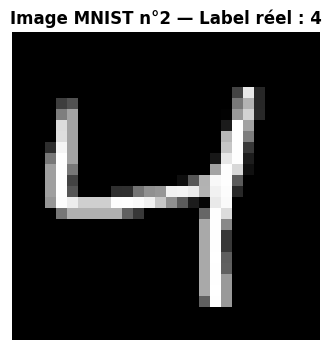

In [98]:
index_image = 2
image_2d = X_raw[index_image].reshape(28, 28)
label_associe = y_raw[index_image]

plt.figure(figsize=(4, 4))
plt.imshow(image_2d, cmap='gray')
plt.title(f"Image MNIST n°{index_image} — Label réel : {label_associe}", fontsize=12, fontweight='bold')
plt.axis('off') 
plt.show()

#### 3.1.2 - Construction de notre réseau de neurones

L'architecture de notre réseau de neurones comporte 1 couche d'entrée, 2 couches cachées et une couche de sortie organisé comme suit:
- une couche d'entrée avec 784 neurones (taille des images MNIST 28x28);
- la première couche cachée avec 128 neurones d'entrées, une fonction d'activation ReLU et un dropout inversé à un taux de 15%;
- la deuxième couche cachée avec 64 neuronnes d'entrées et une fonction d'activation ReLU;
- une couche de sortie avec 10 neurones (les 10 chiffres à classifier) et une fonction d'activation Softmax (classification multi-classes).

La fonction de perte utilisée pour optimiser les poids est l'entropie croisée.

**Nombre total de paramètres de notre réseau**

- Couche 1: $(784 \times 128) + 128 = 100352 + 128 = 100480$
- Couche 2: $(128 \times 64) + 64 = 8192 + 64 = 8256$
- Couche 3: $(64 \times 10) + 10 = 640 + 10 = 650$

$$\text{Total} = 100480 + 8256 + 650 = \mathbf{109 386 \text{ paramètres}}$$

In [99]:
classification_model = SequentialNetwork()
classification_model.add(LinearLayer(in_features=784, out_features=128, l2_lambda=1e-4))
classification_model.add(ReLU())
classification_model.add(InvertedDropout(p=0.15))
classification_model.add(LinearLayer(in_features=128, out_features=64, l2_lambda=1e-4))
classification_model.add(ReLU())
classification_model.add(LinearLayer(in_features=64, out_features=10, l2_lambda=1e-4))
classification_model.add(Softmax())

classification_loss_function = CategoricalCrossEntropy()

#### 3.1.3 - Entraînement du réseau de neurones

In [100]:
classification_learning_rate = 0.02
classification_momentum = 0.9
classification_epochs = 50 # On fera 50 itération sur l'ensemble du jeu de données
classification_batch_size = 256 # On entraine les données sur des batch de taille 256 images

classification_train_losses = []
classification_val_losses = []

for epoch in range(1, classification_epochs + 1):
    # Partitionnement mini-batch
    indices = np.arange(X_train_c.shape[0])
    np.random.shuffle(indices)
    X_shuffled = X_train_c[indices]
    y_shuffled = y_train_c[indices]
    
    epoch_loss = 0.0
    num_batches = int(np.ceil(X_train_c.shape[0] / classification_batch_size))
    
    for b in range(num_batches):
        start = b * classification_batch_size
        end = min(start + classification_batch_size, X_train_c.shape[0])
        
        X_b = X_shuffled[start:end]
        y_b = y_shuffled[start:end]
        
        preds = classification_model.forward(X_b, training=True)
        loss = classification_loss_function.compute(preds, y_b)
        epoch_loss += loss * (end - start)
        
        d_loss = classification_loss_function.gradient(preds, y_b)
        classification_model.backward(d_loss)
        classification_model.update(classification_learning_rate, classification_momentum)
        
    train_loss_avg = epoch_loss / X_train_c.shape[0]
    classification_train_losses.append(train_loss_avg)
    
    # Validation et évaluation
    val_preds = classification_model.forward(X_val_c, training=False)
    val_loss = classification_loss_function.compute(val_preds, y_val_c)
    classification_val_losses.append(val_loss)
    
    if epoch % 5 == 0 or epoch == 1:
        val_acc = np.mean(np.argmax(val_preds, axis=1) == np.argmax(y_val_c, axis=1)) * 100
        print(f"Epoch {epoch:02d}/{classification_epochs} | Train Loss: {train_loss_avg:.4f} | Val Loss: {val_loss:.4f} | Val Accuracy: {val_acc:.2f}%")

Epoch 01/50 | Train Loss: 1.2169 | Val Loss: 0.4525 | Val Accuracy: 86.44%
Epoch 05/50 | Train Loss: 0.2539 | Val Loss: 0.2256 | Val Accuracy: 93.50%
Epoch 10/50 | Train Loss: 0.1569 | Val Loss: 0.1646 | Val Accuracy: 95.38%
Epoch 15/50 | Train Loss: 0.1120 | Val Loss: 0.1391 | Val Accuracy: 95.59%
Epoch 20/50 | Train Loss: 0.0838 | Val Loss: 0.1242 | Val Accuracy: 95.94%
Epoch 25/50 | Train Loss: 0.0669 | Val Loss: 0.1149 | Val Accuracy: 96.44%
Epoch 30/50 | Train Loss: 0.0504 | Val Loss: 0.1100 | Val Accuracy: 96.31%
Epoch 35/50 | Train Loss: 0.0413 | Val Loss: 0.1063 | Val Accuracy: 96.66%
Epoch 40/50 | Train Loss: 0.0344 | Val Loss: 0.1044 | Val Accuracy: 96.53%
Epoch 45/50 | Train Loss: 0.0277 | Val Loss: 0.1066 | Val Accuracy: 96.50%
Epoch 50/50 | Train Loss: 0.0243 | Val Loss: 0.1080 | Val Accuracy: 96.56%


### 3.2 - La regression sur le jeu de données California housing

California housing est un jeu de données contenant des informations immobilières pour le district de Californie aux Etats-unis. L'objectif final avec ce jeu de données est de pouvoir prédire le prix d'une maison connaissant ses caractéristiques.

#### 3.2.1 -  Le chargement et la préparation des données

In [101]:
housing = fetch_california_housing()
X_h, y_h = housing.data[:20000], housing.target[:20000].reshape(-1, 1)

# Normalize features to prevent gradient exploding
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_h_scaled = scaler_X.fit_transform(X_h)
y_h_scaled = scaler_y.fit_transform(y_h)

X_train_full, X_test_r, y_train_full, y_test_r = train_test_split(X_h_scaled, y_h_scaled, test_size=0.2, random_state=42)
X_train_r, X_val_r, y_train_r, y_val_r = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)

In [141]:
X_h[:1]

array([[   8.3252    ,   41.        ,    6.98412698,    1.02380952,
         322.        ,    2.55555556,   37.88      , -122.23      ]])

In [142]:
y_h[:1]

array([[4.526]])

In [40]:
print(housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

#### 3.2.2 -  La construction du réseau de neurones

L'architecture de notre réseau de neurones comporte 1 couche d'entrée, 2 couches cachées et une couche de sortie organisé comme suit:
- une couche d'entrée avec 8 neurones (8 caractéristiques explicatives de notre jeu de données, MedInc, HouseAge,...);
- la première couche cachée avec 32 neurones, une fonction d'activation ReLU et un dropout inversé à un taux de 10%;
- la deuxième couche cachée avec 16 neuronnes et une fonction d'activation ReLU;
- une couche de sortie avec 1 neurones (regression pour calculer le prix d'une maison) et aucune fonction d'activation.

La fonction de perte utilisée pour optimiser les poids est la moyenne du carré de l'erreur.

**Nombre total de paramètres de notre réseau**

- Couche 1: $(8 \times 32) + 32 = 256 + 32 = 288$
- Couche 2: $(32 \times 16) + 16 = 512 + 16 = 528$
- Couche 3: $(16 \times 1) + 1 = 16 + 1 = 17$

$$\text{Total} = 288 + 528 + 17 = \mathbf{833 \text{ paramètres}}$$

In [137]:
regression_model = SequentialNetwork()
regression_model.add(LinearLayer(in_features=8, out_features=32, l2_lambda=1e-4))
regression_model.add(ReLU())
regression_model.add(InvertedDropout(p=0.1))
regression_model.add(LinearLayer(in_features=32, out_features=16, l2_lambda=1e-4))
regression_model.add(ReLU())
regression_model.add(LinearLayer(in_features=16, out_features=1, l2_lambda=1e-4))

regression_loss_function = MSELoss()

#### 3.2.3 - L'entraînement du réseau de neurones

In [138]:
regression_learning_rate = 0.001
regression_momentum = 0.9
regression_epochs = 50
regression_batch_size = 256

regression_train_losses = []
regression_val_losses = []

for epoch in range(1, regression_epochs + 1):
    indices = np.arange(X_train_r.shape[0])
    np.random.shuffle(indices)
    X_shuffled = X_train_r[indices]
    y_shuffled = y_train_r[indices]
    
    epoch_loss = 0.0
    num_batches = int(np.ceil(X_train_r.shape[0] / regression_batch_size))
    
    for b in range(num_batches):
        start = b * regression_batch_size
        end = min(start + regression_batch_size, X_train_r.shape[0])
        
        X_b = X_shuffled[start:end]
        y_b = y_shuffled[start:end]
        
        preds = regression_model.forward(X_b, training=True)
        loss = regression_loss_function.compute(preds, y_b)
        epoch_loss += loss * (end - start)
        
        d_loss = regression_loss_function.gradient(preds, y_b)
        regression_model.backward(d_loss)
        regression_model.update(reg_lr, reg_momentum)
        
    train_loss_avg = epoch_loss / X_train_r.shape[0]
    regression_train_losses.append(train_loss_avg)
    
    # Validation et évaluation
    val_preds = regression_model.forward(X_val_r, training=False)
    val_loss = regression_loss_function.compute(val_preds, y_val_r)
    regression_val_losses.append(val_loss)
    
    if epoch % 5 == 0 or epoch == 1:
        # Pour calculer le MSE dans l'échelle de départ on dénormalise les prédictions
        val_preds_orig = scaler_y.inverse_transform(val_preds)
        val_y_orig = scaler_y.inverse_transform(y_val_r)
        actual_mse = np.mean((val_preds_orig - val_y_orig) ** 2)
        print(f"Epoch {epoch:02d}/{regression_epochs} | Scaled Train Loss: {train_loss_avg:.4f} | Scaled Val Loss: {val_loss:.4f} | Real MSE: ${actual_mse*100000:.2f}")

Epoch 01/50 | Scaled Train Loss: 1.5315 | Scaled Val Loss: 1.2872 | Real MSE: $172207.67
Epoch 05/50 | Scaled Train Loss: 0.4137 | Scaled Val Loss: 0.3706 | Real MSE: $49574.23
Epoch 10/50 | Scaled Train Loss: 0.3624 | Scaled Val Loss: 0.3255 | Real MSE: $43545.19
Epoch 15/50 | Scaled Train Loss: 0.3328 | Scaled Val Loss: 0.3031 | Real MSE: $40546.07
Epoch 20/50 | Scaled Train Loss: 0.3221 | Scaled Val Loss: 0.2982 | Real MSE: $39896.18
Epoch 25/50 | Scaled Train Loss: 0.3100 | Scaled Val Loss: 0.2882 | Real MSE: $38550.76
Epoch 30/50 | Scaled Train Loss: 0.3004 | Scaled Val Loss: 0.2787 | Real MSE: $37279.40
Epoch 35/50 | Scaled Train Loss: 0.2938 | Scaled Val Loss: 0.2671 | Real MSE: $35729.46
Epoch 40/50 | Scaled Train Loss: 0.2821 | Scaled Val Loss: 0.2591 | Real MSE: $34658.60
Epoch 45/50 | Scaled Train Loss: 0.2748 | Scaled Val Loss: 0.2535 | Real MSE: $33911.78
Epoch 50/50 | Scaled Train Loss: 0.2677 | Scaled Val Loss: 0.2503 | Real MSE: $33491.24


### 3.3 - Évaluation des performances

#### 3.3.1 - Les courbes de perte

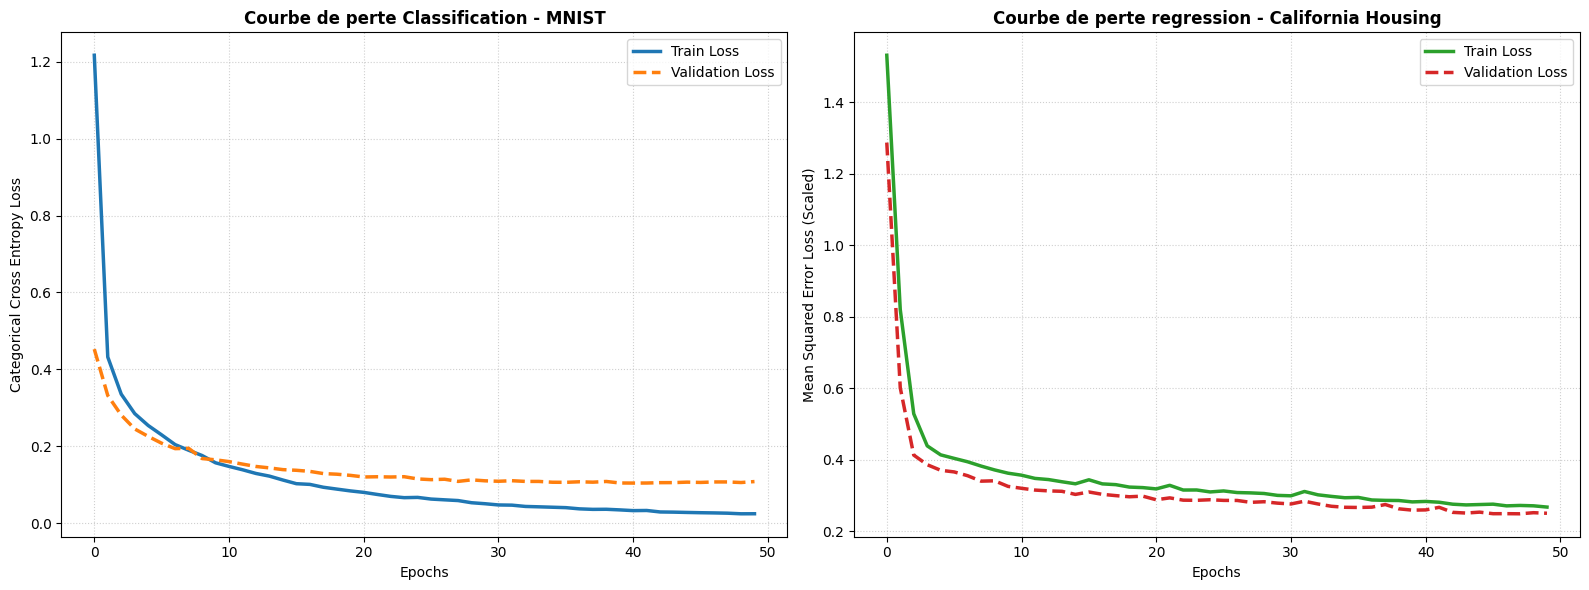

In [139]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graphique 1: Classification sur le jeu de données MNIST
axes[0].plot(classification_train_losses, label='Train Loss', color='#1f77b4', linewidth=2.5)
axes[0].plot(classification_val_losses, label='Validation Loss', color='#ff7f0e', linestyle='--', linewidth=2.5)
axes[0].set_title('Courbe de perte Classification - MNIST', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epochs', fontsize=10)
axes[0].set_ylabel('Categorical Cross Entropy Loss', fontsize=10)
axes[0].legend(fontsize=10)
axes[0].grid(True, linestyle=':', alpha=0.6)

# Graphique 2: Regression sur le jeu de données California Housing 
axes[1].plot(regression_train_losses, label='Train Loss', color='#2ca02c', linewidth=2.5)
axes[1].plot(regression_val_losses, label='Validation Loss', color='#d62728', linestyle='--', linewidth=2.5)
axes[1].set_title('Courbe de perte regression - California Housing', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epochs', fontsize=10)
axes[1].set_ylabel('Mean Squared Error Loss (Scaled)', fontsize=10)
axes[1].legend(fontsize=10)
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

Pour la classification, on constate que la perte commence à un pic maximal puis redescent drastiquement; c'est l'effet d'une bonne initialisation (Initialisation He) et de la puissance du moment, qui dès les premières epochs permet via l'accumulation de vitesse de rattraper le bon sens de convergence. Par la suite, la perte d'entraînement décroît jusqu'à passer en dessous de la perte de validation autour de l'epoch 8. Après l'époque 8, la perte d'entraînement décroît pendant que la perte de validation stagne, signe d'un surapprentissage. La perte de validation n'augmentant pas par la suite, ce surapprentissage est donc maîtrisé, l'architecture de notre réseau a atteint sa capacité maximale.

Pour la regression, on observe d'autres subtilités. La perte d'entraînement reste supérieure à la perte de validation; ceci est dû au dropout inversé, qui pénalise l'entraînement en supprimant des neurones, mais conserve tous les neurones pendant la validation. Le plongeon de la courbe d'entrainement dès les premiers epochs montre encore l'efficacité du moment de la descente de gradient stochastique, qui capture rapidement la bonne direction d'optimisation. 

Dans l'ensemble, on observe pour les deux courbes, une bonne initialisation des poids, une descente du gradient lisse et maitrisé et un contrôle du surapprentissage (grâce au dropout inversé et la régularisation L2).

N.B: les courbes finales ci-dessus on été obtenues après plusieurs tests en modifiant le taux d'apprentissage et la taille des batchs.

#### 3.3.2 - Précision, rappel, F1-score et matrice de confusion pour la classification

In [108]:
def EvaluationClassification(y_true_raw, y_pred_raw, num_classes=10):
    """
    Calcule la matrice de confusion, la précision, 
    le rappel et le F1-score à partir de matrices de probabilités.
    """
    # On convertit les probabilités obtenues avec Softmax en étiquettes (0 à 9)
    if y_true_raw.ndim > 1:
        y_true = np.argmax(y_true_raw, axis=1) # L'index de la plus grande probabilité correspond à son étiquette
    else:
        y_true = y_true_raw
        
    if y_pred_raw.ndim > 1:
        y_pred = np.argmax(y_pred_raw, axis=1)
    else:
        y_pred = y_pred_raw

    # Matrice de Confusion (Vectorisée)
    # Lignes = Classes Réelles (i), Colonnes = Classes Prédites(j)
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for i in range(num_classes):
        for j in range(num_classes):
            cm[i, j] = np.sum((y_true == i) & (y_pred == j))

    # Calcul des métriques par classe
    precision_par_classe = np.zeros(num_classes)
    rappel_par_classe = np.zeros(num_classes)
    f1_par_classe = np.zeros(num_classes)

    for c in range(num_classes):
        tp = cm[c, c]                  # Vrais Positifs : la diagonale, les éléments prédits de la classe et qui le sont vraiment
        fp = np.sum(cm[:, c]) - tp     # Faux Positifs : On retire à tous les éléments prédits de cette classe ceux qui le sont vraiment
        fn = np.sum(cm[c, :]) - tp     # Faux Négatifs : À tous les éléments qui sont de la classe, on retire les vrais positifs

        # Sécurité division par zéro (si aucune prédiction ou aucun vrai label pour cette classe)
        precision_par_classe[c] = tp / (tp + fp) if (tp + fp) > 0 else 0.0 # Les prédictions correctes
        rappel_par_classe[c] = tp / (tp + fn) if (tp + fn) > 0 else 0.0    # Parmis les vrais, ceux qui ont été détectés
        
        p = precision_par_classe[c]
        r = rappel_par_classe[c]
        f1_par_classe[c] = 2 * (p * r) / (p + r) if (p + r) > 0 else 0.0

    # Calcul des moyennes globales (Macro-Averaging)
    macro_precision = np.mean(precision_par_classe)
    macro_recall = np.mean(rappel_par_classe)
    macro_f1 = np.mean(f1_par_classe)

    return {
        "matrice_confusion": cm,
        "precision_classe": precision_par_classe,
        "rappel_classe": rappel_par_classe,
        "f1_classe": f1_par_classe,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1
    }

In [109]:
def AfficherRapportPerformance(metrics):
    """
    Affiche proprement les résultats sous forme de tableau.
    """
    print("\n" + "="*55)
    print("        RAPPORT DE PERFORMANCE DE CLASSIFICATION        ")
    print("="*55)
    print(f"{'Classe':<10} | {'Précision':<10} | {'Rappel':<10} | {'F1-Score':<10}")
    print("-"*55)
    
    for c in range(len(metrics["precision_classe"])):
        print(f"Chiffre {c:<2} | {metrics['precision_classe'][c]:<10.4f} | {metrics['rappel_classe'][c]:<10.4f} | {metrics['f1_classe'][c]:<10.4f}")
        
    print("-"*55)
    print(f"{'MOYENNE (Macro)':<10} | {metrics['macro_precision']:<10.4f} | {metrics['macro_recall']:<10.4f} | {metrics['macro_f1']:<10.4f}")
    print("="*55)
    
    print("\nMATRICE DE CONFUSION :")
    print(metrics["matrice_confusion"])

In [110]:
predictions_validation = classification_model.forward(X_test_c, training=False)
rapport_brut = EvaluationClassification(y_test_c, predictions_validation, num_classes=10)
AfficherRapportPerformance(rapport_brut)


        RAPPORT DE PERFORMANCE DE CLASSIFICATION        
Classe     | Précision  | Rappel     | F1-Score  
-------------------------------------------------------
Chiffre 0  | 0.9701     | 0.9873     | 0.9786    
Chiffre 1  | 0.9731     | 0.9895     | 0.9813    
Chiffre 2  | 0.9729     | 0.9651     | 0.9690    
Chiffre 3  | 0.9597     | 0.9666     | 0.9631    
Chiffre 4  | 0.9688     | 0.9563     | 0.9625    
Chiffre 5  | 0.9663     | 0.9488     | 0.9574    
Chiffre 6  | 0.9730     | 0.9826     | 0.9778    
Chiffre 7  | 0.9688     | 0.9806     | 0.9747    
Chiffre 8  | 0.9740     | 0.9280     | 0.9504    
Chiffre 9  | 0.9483     | 0.9625     | 0.9553    
-------------------------------------------------------
MOYENNE (Macro) | 0.9675     | 0.9667     | 0.9670    

MATRICE DE CONFUSION :
[[389   0   0   0   0   0   3   0   1   1]
 [  0 471   1   2   0   0   0   0   1   1]
 [  1   1 359   4   2   0   1   3   1   0]
 [  0   0   1 405   0   5   0   2   3   3]
 [  0   2   0   0 372   0   2

Notre modèle de classiffication est assez robuste. Avec une précision globale de 96.8% et un rappel global de 96.7%, il a raison a plus de 95% chaque fois qu'il fait une prédiction et réussi à capturer plus de 96% des chiffres présents dans le jeu de test. La précision et le rappel étant presque identiques, le score F1 est lui aussi similaire, de 96.7%. On a donc un modèle dans l'ensemble pas trop timide (il n'a pas trop peur de se tromper) et pas trop agressif non plus (pas trop enthousiaste dans ses prédictions).

Par contre, notre modèle est très timide dans la prédiction du chiffre 8 (précision (0.9740) > rappel (0.9280)), et très agressif dans la prédiction du chiffre 9 (rappel (0.9625) > précision (0.9483)).

#### 3.3.3 - MSE, RMSE, score R² et graphique des résidus pour la regression

In [113]:
def EvaluationRegression(y_true_raw, y_pred_raw):
    """
    Calcule manuellement la MAE, la RMSE et le score R²
    """
    # On aplatit en vecteurs 1D pour éviter les bugs de broadcasting
    y_true = y_true_raw.flatten()
    y_pred = y_pred_raw.flatten()
    
    # Calcul de la MAE (Mean Absolute Error)
    mae = np.mean(np.abs(y_true - y_pred))
    
    # Calcul de la RMSE (Root Mean Squared Error)
    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)
    
    # Calcul du Score R² (Coefficient de détermination)
    somme_residus = np.sum((y_true - y_pred) ** 2)
    somme_totale = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1.0 - (somme_residus / somme_totale) if somme_totale > 0 else 0.0
    
    return {
        "mae": mae,
        "rmse": rmse,
        "r2": r2
    }

In [120]:
def TracerGraphiqueResidus(y_true_raw, y_pred_raw):
    """
    Génère un graphique des résidus pour analyser les erreurs de prédiction.
    """
    y_true = y_true_raw.flatten()
    y_pred = y_pred_raw.flatten()
    
    # Résidu = Valeur Réelle - Valeur Prédite
    residus = y_true - y_pred
    
    plt.figure(figsize=(9, 5))
    plt.scatter(y_pred, residus, color='forestgreen', alpha=0.5, edgecolors='k', s=25)
    
    # Ligne horizontale idéale à y = 0 (zéro erreur)
    plt.axhline(y=0, color='black', linestyle='--', linewidth=2, label='Prédiction Parfaite')
    
    plt.title("Graphique des Résidus (Analyse des Erreurs)", fontsize=12, fontweight='bold')
    plt.xlabel("Valeurs Prédites par le Modèle ($\hat{y}$)", fontsize=10)
    plt.ylabel("Résidus ($y - \hat{y}$)", fontsize=10)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    plt.show()

In [118]:
def AfficherRapportRegression(metrics):
    """
    Affiche proprement les métriques scalaires.
    """
    print("\n" + "="*45)
    print("        RAPPORT DE PERFORMANCE RÉGRESSION        ")
    print("="*45)
    print(f"Erreur Absolue Moyenne (MAE)  : {metrics['mae']:.4f}")
    print(f"Racine de l'Erreur au Carré (RMSE) : {metrics['rmse']:.4f}")
    print(f"Coefficient de Détermination (R²) : {metrics['r2']:.4f}")
    print("="*45)


        RAPPORT DE PERFORMANCE RÉGRESSION        
Erreur Absolue Moyenne (MAE)  : 0.3455
Racine de l'Erreur au Carré (RMSE) : 0.4927
Coefficient de Détermination (R²) : 0.7553


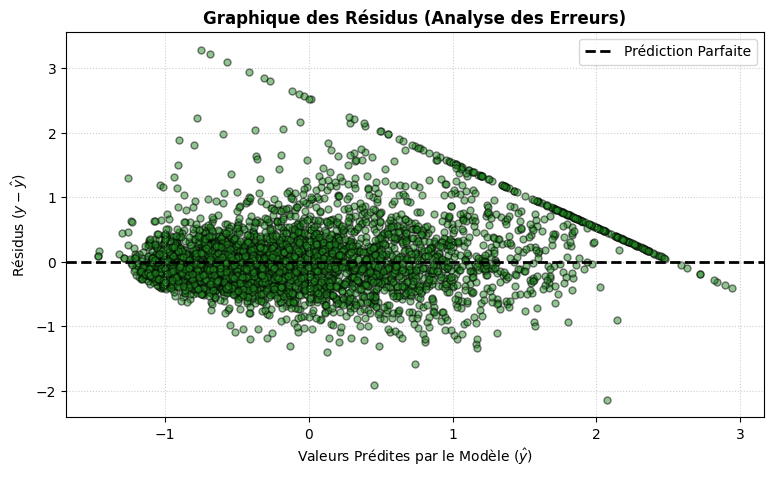

In [140]:
predictions_test_reg = regression_model.forward(X_test_r, training=False)
stats_regression = EvaluationRegression(y_test_r, predictions_test_reg)

AfficherRapportRegression(stats_regression)
TracerGraphiqueResidus(y_test_r, predictions_test_reg)

Avec une MAE à 0.3455, si notre modèle prédit qu'une maison coûte 100 000\\$, il s'est trompé en moyenne de 34 550\\$. La RMSE vient préciser le plafond de cette erreur, qui est de 49 270\\$. Le coefficient de détermination nous explique que notre réseau de neuronnes explique 75.53% de la variance du prix de l'immobilier dans le district de Californie, ce qui est un score assez interressant.

Le graphe de résidu nous montre une répartition assez équilibrée de part et d'autre de la valeur centrale 0; cela signifie que notre réseau de neuronnes ne surestime, ni ne sous estime les prix de manière globale. Par contre la ligne parfaitement droite décroissante à droite du graphique n'est pas dûe au hasard; elle est la signature d'un traitement spécial du jeu de données California housing, qui transforme toutes les valeurs atypiques (villas dont le prix est supérieure à 500 000\\$ à exactement 500 000\\$ (valeur 5 dans le vecteur y). 

## 4 - Conclusion

En fin de compte, nous avons implémenté l'architecture du code d'un réseau de neuronnes; partant de cette architecture nous avons contruit un réseau de neurones pour la classification multi-classes et un autre pour la regression. 

Les performances observées pour chacun de ces réseau montre à suffisance la pertinence de l'hypothèse du théorème d'approximation universelle. En considérant encore le traitement minimal réalisé sur les données (de simples standardisations) avant l'entraînement des réseaux, on apprécie d'avantage la simplicité d'utilisation des réseaux de neuronnes comparée à la performance qu'ils proposent.